# 0. 프로젝트: SentencePiece 사용하기

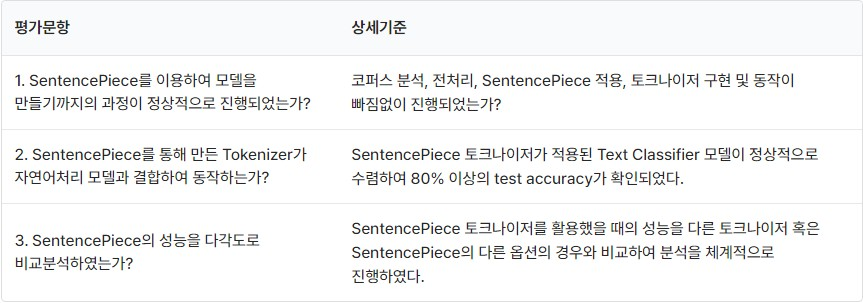

In [1]:
import os, re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# !pip install sentencepiece
import sentencepiece as spm
# !pip install konlpy
import konlpy

import tensorflow as tf
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split

In [2]:
tf.random.set_seed(9)
np.random.seed(9)

In [3]:
env = os.getenv('HOME') + '/aiffel/sp_tokenizer/data'

# 1. 데이터 불러오기

In [4]:
ratings_train = pd.read_table(env + '/ratings_train.txt')
ratings_test = pd.read_table(env + '/ratings_test.txt')

In [5]:
ratings_train.tail()

,id,document,label
149995,6222902,인간이 문제지.. 소는 뭔죄인가..,0
149996,8549745,평점이 너무 낮아서...,1
149997,9311800,이게 뭐요? 한국인은 거들먹거리고 필리핀 혼혈은 착하다?,0
149998,2376369,청춘 영화의 최고봉.방황과 우울했던 날들의 자화상,1
149999,9619869,한국 영화 최초로 수간하는 내용이 담긴 영화,0


In [6]:
ratings_test.head()

,id,document,label
0,6270596,굳 ㅋ,1
1,9274899,GDNTOPCLASSINTHECLUB,0
2,8544678,뭐야 이 평점들은.... 나쁘진 않지만 10점 짜리는 더더욱 아니잖아,0
3,6825595,지루하지는 않은데 완전 막장임... 돈주고 보기에는....,0
4,6723715,3D만 아니었어도 별 다섯 개 줬을텐데.. 왜 3D로 나와서 제 심기를 불편하게 하죠??,0


In [7]:
ratings_train = ratings_train.drop_duplicates(subset=['document']).dropna(how='any').reset_index(drop=True)
ratings_test = ratings_test.drop_duplicates(subset=['document']).dropna(how='any').reset_index(drop=True)


In [8]:
ratings_train.iloc[-1]['id']

9619869

In [9]:
train_end_id = ratings_train.iloc[-1]['id']
print(train_end_id)

9619869


# 2. 코퍼스 분석하기

In [10]:
ratings = pd.concat([ratings_train, ratings_test]).reset_index(drop=True)
ratings

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1
...,...,...,...
195334,4608761,오랜만에 평점 로긴했네ㅋㅋ 킹왕짱 쌈뽕한 영화를 만났습니다 강렬하게 육쾌함,1
195335,5308387,의지 박약들이나 하는거다 탈영은 일단 주인공 김대희 닮았고 이등병 찐따 OOOO,0
195336,9072549,그림도 좋고 완성도도 높았지만... 보는 내내 불안하게 만든다,0
195337,5802125,절대 봐서는 안 될 영화.. 재미도 없고 기분만 잡치고.. 한 세트장에서 다 해먹네,0


In [11]:
def cal_sentence_length(raw):
    sen_lens = [len(sen) for sen in raw]

    print("문장의 최단 길이:", min(sen_lens))
    print("문장의 최장 길이:", max(sen_lens))
    print("문장의 평균 길이:", sum(sen_lens) // len(raw))

    sentence_length = np.zeros((max(sen_lens)), dtype=np.int)

    for i in range(max(sen_lens)):
        sentence_length[i] += sen_lens.count(i)

    plt.bar(range(max(sen_lens)), sentence_length, width=1.0)
    plt.title("Sentence Length Distribution")
    plt.show()

문장의 최단 길이: 1
문장의 최장 길이: 146
문장의 평균 길이: 35


/tmp/ipykernel_1663/3097477280.py:8: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  sentence_length = np.zeros((max(sen_lens)), dtype=np.int)


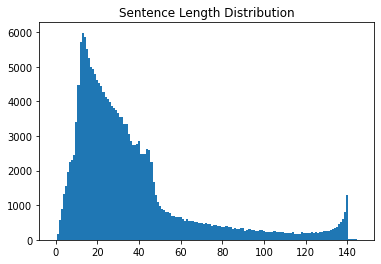

In [12]:
cal_sentence_length(ratings['document'])

In [13]:
def check_sentence_with_length(raw, length):
    count = 0
    sen_list = []
    
    for sen in raw:
        if len(sen) == length:
            sen_list.append(sen)
            count += 1
            if count > 100:
                return sen_list

In [14]:
print(check_sentence_with_length(ratings['document'], 1))

['아', '잼', '1', '4', '굿', '짱', '휴', '.', '음', '?', 'ㅎ', 'ㅋ', '즐', '♥', '굳', '네', 'ㅇ', 'k', 'ㅠ', '쒯', '♬', '토', 'O', '똥', 'z', '헐', '삼', '꽝', '!', '풉', 'ㅅ', '왜', 'ㄴ', '쉣', '봐', '뿌', 'ㅜ', '♡', 'ㅁ', '0', 'ㅉ', 'd', '흥', '乃', '찜', '귯', '린', '시', 'ㅗ', 'a', 'c', '흠', '웅', 'ㅣ', '오', '9', '쩜', '애', '헝', '쨩', 'f', '움', 'ㄳ', '업', '헉', '군', 'b', ';', 'g', '올', '걍', '허', '-', '쀍', '로', 'ㄹ', 'ㅂ', '갑', '즛', '킥', '함', '진', 'ㅡ', '잠', '곧', 'ㅍ', 'h', '·', '캬', 'ㅆ', ',', '풋', 'ㄱ', '파', 'ㄷ', '웩', '꺅', '욜', 'ㅄ', '2', '핡']


# 3. 전처리하기

In [15]:
# 전처리 함수
def preprocess_sentence(sentence):
    sentence = sentence.lower()
    # 단어와 구두점(punctuation) 사이의 거리를 만듭니다.
    # 예를 들어서 "I am a student." => "I am a student ."와 같이
    # student와 온점 사이에 거리를 만듭니다.
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    # (a-z, A-Z, ".", "?", "!", ",")를 제외한 모든 문자를 공백인 ' '로 대체합니다.
    sentence = re.sub(r"[^a-zA-Zㄱ-ㅣ가-힣0-9?.!,]+", " ", sentence)
    sentence = sentence.strip()
    
    return sentence

In [16]:
preprocess_sentence('  ㄱ     A         B    ㅗ    ')

'ㄱ a b ㅗ'

In [17]:
ratings['document'] = ratings['document'].apply(preprocess_sentence)
ratings.head()

,id,document,label
0,9976970,아 더빙 . . 진짜 짜증나네요 목소리,0
1,3819312,흠 . . . 포스터보고 초딩영화줄 . . . . 오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 . . 솔직히 재미는 없다 . . 평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화 ! 스파이더맨에서 늙어보이기만 했던 커스...,1


In [18]:
# point
min_len = 2 ** 2
max_len = 2 ** 6

In [19]:
# 길이 조건에 맞는 문장만 선택합니다.
ratings = ratings[ratings['document'].apply(lambda x: min_len <= len(x) <= max_len)]
print("Data Size:", len(ratings))


Data Size: 166396


문장의 최단 길이: 4
문장의 최장 길이: 64
문장의 평균 길이: 27


/tmp/ipykernel_1663/3097477280.py:8: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  sentence_length = np.zeros((max(sen_lens)), dtype=np.int)


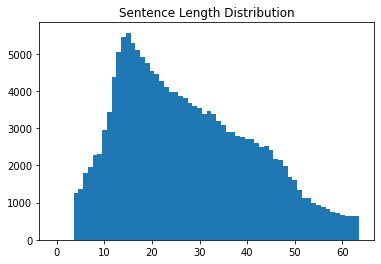

In [20]:
cal_sentence_length(ratings['document'])

In [21]:
ratings

,id,document,label
0,9976970,아 더빙 . . 진짜 짜증나네요 목소리,0
1,3819312,흠 . . . 포스터보고 초딩영화줄 . . . . 오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 . . 솔직히 재미는 없다 . . 평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화 ! 스파이더맨에서 늙어보이기만 했던 커스...,1
...,...,...,...
195334,4608761,오랜만에 평점 로긴했네ㅋㅋ 킹왕짱 쌈뽕한 영화를 만났습니다 강렬하게 육쾌함,1
195335,5308387,의지 박약들이나 하는거다 탈영은 일단 주인공 김대희 닮았고 이등병 찐따 oooo,0
195336,9072549,그림도 좋고 완성도도 높았지만 . . . 보는 내내 불안하게 만든다,0
195337,5802125,절대 봐서는 안 될 영화 . . 재미도 없고 기분만 잡치고 . . 한 세트장에서 다...,0


In [22]:
ratings.isna().sum()

id          0
document    0
label       0
dtype: int64

# 4. SentencePiece 모델 학습하기

In [23]:
temp_file = env + '/ratings.txt.temp'

with open(temp_file, 'w') as f:
    for row in ratings['document']:   # 이전 스텝에서 정제했던 corpus를 활용합니다.
        f.write(str(row) + '\n')

vocab_size = 2 ** 11 # point

spm.SentencePieceTrainer.Train('--input={} --model_prefix=korean_spm --vocab_size={}'.format(temp_file, vocab_size))

#위 Train에서  --model_type = 'unigram'이 디폴트 적용되어 있습니다. --model_type = 'bpe' 로 옵션을 주어 변경할 수 있습니다.

!ls -l korean_spm*

sentencepiece_trainer.cc(177) LOG(INFO) Running command: --input=/aiffel/aiffel/sp_tokenizer/data/ratings.txt.temp --model_prefix=korean_spm --vocab_size=2048
sentencepiece_trainer.cc(77) LOG(INFO) Starts training with : 
trainer_spec {
  input: /aiffel/aiffel/sp_tokenizer/data/ratings.txt.temp
  input_format: 
  model_prefix: korean_spm
  model_type: UNIGRAM
  vocab_size: 2048
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_

-rw-r--r-- 1 root root 264256 Nov 24 01:12 korean_spm.model
-rw-r--r-- 1 root root  28383 Nov 24 01:12 korean_spm.vocab


In [24]:
s = spm.SentencePieceProcessor()
s.Load('korean_spm.model')

# SentencePiece를 활용한 sentence -> encoding
tokensIDs = s.EncodeAsIds('아버지가방에들어가신다.')
print(tokensIDs)

# SentencePiece를 활용한 sentence -> encoded pieces
print(s.SampleEncodeAsPieces('아버지가방에들어가신다.', 1, 0.0))

# SentencePiece를 활용한 encoding -> sentence 복원
print(s.DecodeIds(tokensIDs))

[37, 149, 14, 7, 269, 17, 41, 25, 7, 112, 6, 2044]
['▁아', '버', '지', '가', '방', '에', '들', '어', '가', '신', '다', '.']
아버지가방에들어가신다.


# 5. Tokenizer 함수 작성하기

In [25]:
def sp_tokenize(s, corpus):

    tensor = []

    for sen in corpus:
        tensor.append(s.EncodeAsIds(sen))

    with open("./korean_spm.vocab", 'r') as f:
        vocab = f.readlines()

    word_index = {}
    index_word = {}

    for idx, line in enumerate(vocab):
        word = line.split("\t")[0]

        word_index.update({word:idx})
        index_word.update({idx:word})

    tensor = tf.keras.preprocessing.sequence.pad_sequences(tensor, padding='post')

    return tensor, word_index, index_word

In [26]:
#sp_tokenize(s, corpus) 사용예제

my_corpus = ['나는 밥을 먹었습니다.', '그러나 여전히 ㅠㅠ 배가 고픕니다...']
print(sp_tokenize(s, my_corpus)[0])

[[   3  514    3 1174   15    3  276  113  100 2044    0    0    0    0
     0    0]
 [  43   78   24  175   84  102  356  715    7    3   11 1950  300 2044
  2044 2044]]


In [27]:
ratings_X, word_index, index_word = sp_tokenize(s, ratings['document'])

In [28]:
for i, tokens in enumerate(ratings_X[: 5]):
    print([index_word[token] for token in tokens if index_word[token] != '<unk>'])
    print(ratings['label'].iloc[i])

['▁아', '▁더', '빙', '▁.', '▁.', '▁진짜', '▁', '짜', '증', '나', '네요', '▁', '목', '소', '리']
0
['▁', '흠', '▁.', '▁.', '▁.', '▁', '포', '스', '터', '보고', '▁', '초', '딩', '영화', '줄', '▁.', '▁.', '▁.', '▁.', '▁오', '버', '연기', '조', '차', '▁', '가', '볍', '지', '▁않', '구나']
1
['▁너무', '재', '밓', '었다', '그', '래', '서', '보는', '것', '을', '추', '천', '한다']
0
['▁', '교', '도', '소', '▁이야기', '구', '먼', '▁.', '▁.', '▁솔직히', '▁재미', '는', '▁없다', '▁.', '▁.', '▁평점', '▁조', '정']
0
['▁사', '이', '몬', '페', '그', '의', '▁', '익', '살', '스', '런', '▁연기', '가', '▁', '돋', '보', '였', '던', '▁영화', '▁!', '▁스', '파', '이', '더', '맨', '에서', '▁', '늙', '어', '보', '이', '기', '만', '▁', '했던', '▁', '커', '스', '틴', '▁', '던', '스트', '가', '▁너무', '나', '도', '▁이', '뻐', '보', '였다']
1


In [29]:
print(ratings_X.shape)
ratings_X

(166396, 63)


array([[  37,   99, 1216, ...,    0,    0,    0],
       [   3, 1041,    4, ...,    0,    0,    0],
       [  32,  265, 1872, ...,    0,    0,    0],
       ...,
       [  43,  416,   13, ...,    0,    0,    0],
       [   3,  383,   57, ...,    0,    0,    0],
       [ 250,  182,  684, ...,    0,    0,    0]], dtype=int32)

In [30]:
train_end_idx = np.array(range(len(ratings)))[ratings['id'] == train_end_id][0]

train_end_idx

124616

In [31]:
ratings.iloc[train_end_idx]

id                           9619869
document    한국 영화 최초로 수간하는 내용이 담긴 영화
label                              0
Name: 146181, dtype: object

In [32]:
train_X = ratings_X[: train_end_idx+1]
test_X = ratings_X[train_end_idx+1: ]

train_y = np.array(ratings['label'][: train_end_idx+1], dtype='float32')
test_y = np.array(ratings['label'][train_end_idx+1: ], dtype='float32')

In [33]:
print(train_X.shape)
print(test_X.shape)

print(train_y.shape)
print(test_y.shape)

(124617, 63)
(41779, 63)
(124617,)
(41779,)


# 6. validation set 구성 및 모델 구성

In [34]:
def tsize(train_X):
    length = len(train_X)
    return round(0.14 * (1 + length / 10 ** 4) ** (10 ** 4 / length) - 0.13, 2)

tsize(train_X)


0.04

In [35]:
X_train, X_val, y_train, y_val = train_test_split(train_X, train_y, test_size=tsize(train_X))


In [36]:
print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

(119632, 63)
(4985, 63)
(119632,)
(4985,)


In [37]:
# point
class model_maker(tf.keras.Model):
    def __init__(self, vocab_size, word_vector_dim, units):
        super().__init__()
        self.embedding = layers.Embedding(vocab_size, word_vector_dim, input_shape=(None, ))
        self.lstm1 = layers.LSTM(units, return_sequences=True)
        self.dropout1 = layers.Dropout(0.5)
        self.lstm2 = layers.LSTM(int(units / 2 ** 1), return_sequences=True)
        self.flatten = layers.Flatten()
        self.dense1 = layers.Dense(int(units / 2 ** 1))
        self.dropout2 = layers.Dropout(0.5)
        self.dense2 = layers.Dense(1, activation='sigmoid')
        
    def call(self, x):
        x = self.embedding(x)
        x = self.lstm1(x)
        x = self.dropout1(x)
        x = self.lstm2(x)
        x = self.flatten(x)
        x = self.dense1(x)
        x = self.dropout2(x)
        x = self.dense2(x)
        
        return x


In [38]:
# point
word_vector_dim = 2 ** 6
units = 2 ** 5

model = model_maker(vocab_size, word_vector_dim, units)

# 7. 모델 훈련하기

In [39]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
              
epochs = 2 ** 6

early_stop = EarlyStopping(monitor='val_loss', verbose=1, patience=2**3)

history = model.fit(X_train,
                    y_train,
                    epochs=epochs,
                    batch_size=2**10, # point
                    validation_data=(X_val, y_val),
                    verbose=1,
                   callbacks=[early_stop])

Epoch 1/64
117/117 [==============================] - 17s 31ms/step - loss: 0.4943 - accuracy: 0.7565 - val_loss: 0.4076 - val_accuracy: 0.8082
Epoch 2/64
117/117 [==============================] - 2s 20ms/step - loss: 0.4158 - accuracy: 0.8142 - val_loss: 0.4039 - val_accuracy: 0.8112
Epoch 3/64
117/117 [==============================] - 3s 24ms/step - loss: 0.4026 - accuracy: 0.8197 - val_loss: 0.3859 - val_accuracy: 0.8183
Epoch 4/64
117/117 [==============================] - 3s 24ms/step - loss: 0.3854 - accuracy: 0.8278 - val_loss: 0.3785 - val_accuracy: 0.8255
Epoch 5/64
117/117 [==============================] - 3s 25ms/step - loss: 0.3750 - accuracy: 0.8316 - val_loss: 0.3807 - val_accuracy: 0.8243
Epoch 6/64
117/117 [==============================] - 3s 24ms/step - loss: 0.3651 - accuracy: 0.8368 - val_loss: 0.3675 - val_accuracy: 0.8279
Epoch 7/64
117/117 [==============================] - 3s 24ms/step - loss: 0.3528 - accuracy: 0.8437 - val_loss: 0.3617 - val_accuracy: 0.833

In [40]:
result = model.evaluate(test_X,  test_y, verbose=2)

1306/1306 - 8s - loss: 0.3981 - accuracy: 0.8406


In [41]:
0.8377

0.8377

# 8. 회고하기